In [1]:
pip install emcee

  Using cached emcee-3.1.6-py2.py3-none-any.whl.metadata (3.0 kB)
Using cached emcee-3.1.6-py2.py3-none-any.whl (47 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install corner

  Using cached corner-2.3.0-py3-none-any.whl.metadata (2.3 kB)
Using cached corner-2.3.0-py3-none-any.whl (16 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install sbi

  Using cached sbi-0.27.0-py3-none-any.whl.metadata (16 kB)
  Using cached nflows-0.14-py3-none-any.whl
  Using cached skorch-1.4.0-py3-none-any.whl.metadata (11 kB)
  Using cached zuko-1.6.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
Using cached sbi-0.27.0-py3-none-any.whl (545 kB)
Using cached zuko-1.6.0-py3-none-any.whl (48 kB)
Using cached skorch-1.4.0-py3-none-any.whl (271 kB)
Using cached tabulate-0.10.0-py3-none-any.whl (39 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [sbi]4/5 [sbi]ws]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee as mcmc
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch


/opt/conda/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
2026-09-11 17:22:31.486898: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 17:22:31.519198: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
coin_bias = 0.5
nflips = 100
flips = np.random.binomial(1, coin_bias, nflips)
heads = flips.sum()
tails = nflips - heads

a_prior, b_prior = 1, 1 
a_post = 

SyntaxError: invalid syntax (1140164070.py, line 8)

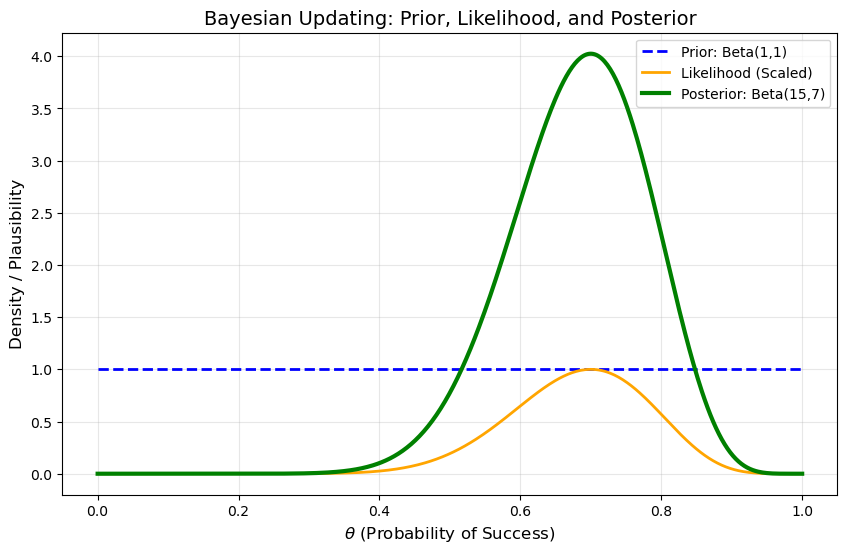

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# 1. Define parameter space (theta) and observed data
theta = np.linspace(0, 1, 500)
n_flips = 20      # Total number of trials (e.g., coin flips)
k_success = 14    # Number of observed successes (e.g., heads)

# 2. Prior distribution: Beta(alpha, beta) - using a flat/uninformative prior Beta(1, 1)
alpha_prior, beta_prior = 1, 1
prior_density = beta.pdf(theta, alpha_prior, beta_prior)

# 3. Likelihood function: Binomial data given theta (scaled for visualization)
likelihood_raw = binom.pmf(k_success, n_flips, theta)
likelihood_scaled = likelihood_raw / np.max(likelihood_raw) # Scale for visual comparison

# 4. Posterior distribution: Beta(alpha + k, beta + n - k)
alpha_post = alpha_prior + k_success
beta_post = beta_prior + (n_flips - k_success)
posterior_density = beta.pdf(theta, alpha_post, beta_post)

# 5. Plotting the distributions
plt.figure(figsize=(10, 6))
plt.plot(theta, prior_density, label='Prior: Beta(1,1)', color='blue', linestyle='--', linewidth=2)
plt.plot(theta, likelihood_scaled, label='Likelihood (Scaled)', color='orange', linestyle='-', linewidth=2)
plt.plot(theta, posterior_density, label=f'Posterior: Beta({alpha_post},{beta_post})', color='green', linestyle='-', linewidth=3)

plt.title('Bayesian Updating: Prior, Likelihood, and Posterior', fontsize=14)
plt.xlabel(r'$\theta$ (Probability of Success)', fontsize=12)
plt.ylabel('Density / Plausibility', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


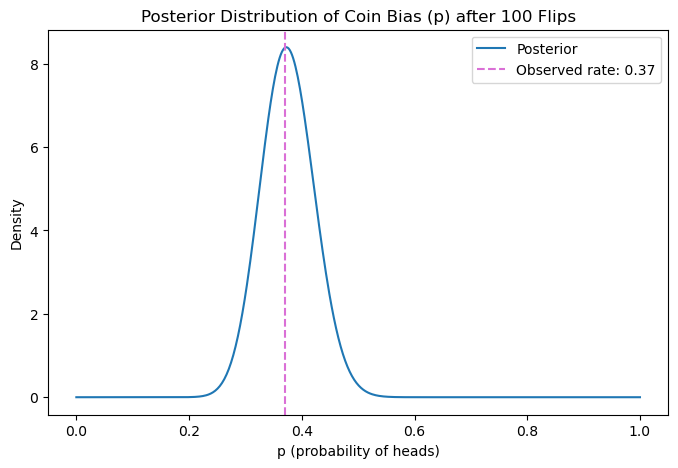

Heads: 37, Tails: 63
Posterior mean: 0.375


In [23]:
coin_bias = 0.4
n_flips = 100
flips = np.random.binomial(1, coin_bias, n_flips)
heads = flips.sum()
tails = n_flips - heads

a_prior, b_prior = 2, 2          
a_post = a_prior + heads
b_post = b_prior + tails

x = np.linspace(0, 1, 500)
posterior = beta.pdf(x, a_post, b_post)

plt.figure(figsize=(8, 5))
plt.plot(x, posterior, label=f'Posterior')
plt.axvline(heads/n_flips, color = 'orchid', linestyle='--', label=f'Observed rate: {heads/n_flips:.2f}')
plt.title(f'Posterior Distribution of Coin Bias (p) after {n_flips} Flips')
plt.xlabel('p (probability of heads)')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Heads: {heads}, Tails: {tails}")
print(f"Posterior mean: {a_post / (a_post + b_post):.3f}")

Coin prob=0.3 -> Heads: 23, Tails: 77, Posterior mean: 0.231
Coin prob=0.5 -> Heads: 49, Tails: 51, Posterior mean: 0.488
Coin prob=0.7 -> Heads: 56, Tails: 44, Posterior mean: 0.557


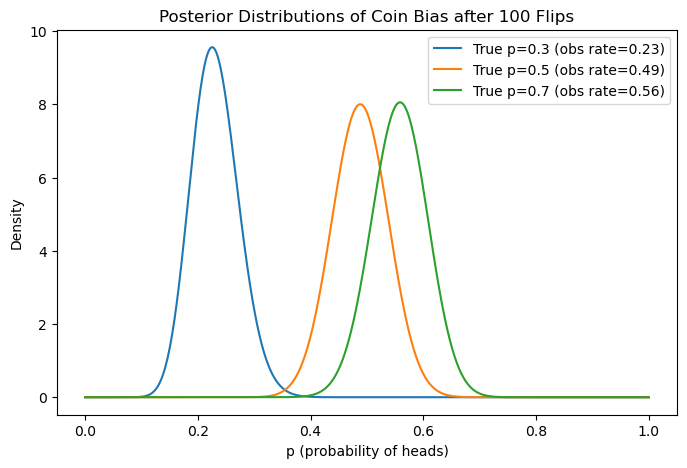

In [21]:
coin_bias = (0.3, 0.5, 0.7)
n_flips = 100
a_prior, b_prior = 1, 1

x = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 5))

for num in coin_bias:
    flips = np.random.binomial(1, num, n_flips)
    heads = flips.sum()
    tails = n_flips - heads

    a_post = a_prior + heads
    b_post = b_prior + tails

    posterior = beta.pdf(x, a_post, b_post)

    plt.plot(x, posterior, label=f'True p={num} (obs rate={heads/n_flips:.2f})')

    print(f"Coin prob={num} -> Heads: {heads}, Tails: {tails}, "
          f"Posterior mean: {a_post / (a_post + b_post):.3f}")

plt.title(f'Posterior Distributions of Coin Bias after {n_flips} Flips')
plt.xlabel('p (probability of heads)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [15]:
import torch
from sbi.inference import NPE

# define shifted Gaussian simulator.
def simulator(θ): return θ + torch.randn_like(θ)
# draw parameters from Gaussian prior.
θ = torch.randn(1000, 2)
# simulate data
x = simulator(θ)

# choose sbi method and train
inference = NPE()
inference.append_simulations(θ, x).train()

# do inference given observed data
x_o = torch.ones(2)
posterior = inference.build_posterior()
samples = posterior.sample((1000,), x=x_o)

 Neural network successfully converged after 341 epochs.

  0%|          | 0/1000 [00:00<?, ?it/s]

## sbi package example

In [28]:
pip install pyro

  Preparing metadata (setup.py) ... error
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [7 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 35, in <module>
        File "/tmp/pip-install-w7y_4_8o/pyro_d5ec84072c7a4a8186d36073e05de2b1/setup.py", line 23
          exec code in constants
          ^^^^^^^^^^^^^^^^^^^^^^
      SyntaxError: Missing parentheses in call to 'exec'. Did you mean exec(...)?
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Note: you may need to restart the kernel to use updated packages.


In [29]:
import matplotlib.pyplot as plt
import torch
from example_01_utils import BinomialGammaPotential
from pyro.distributions import InverseGamma
from torch import Tensor
from torch.distributions import Beta, Binomial, Gamma

from sbi.analysis import pairplot
from sbi.inference import MNLE, MCMCPosterior
from sbi.inference.posteriors.posterior_parameters import MCMCPosteriorParameters
from sbi.inference.potentials.likelihood_based_potential import LikelihoodBasedPotential
from sbi.neural_nets import likelihood_nn
from sbi.utils import BoxUniform, MultipleIndependent, mcmc_transform
from sbi.utils.metrics import c2st

ModuleNotFoundError: No module named 'pyro'